## SPRINT 11 - Visualización de Datos - sin maquetar

RAFAEL FONS BIBILONI

In [11]:
## NIVEL 1 - Ejercicio 1

# Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.

from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de conexión
user = "powerbi_VM_mysql"
password = "Fredy-2020"
host = "127.0.0.1"
port = 3306
database = "sprint7"

try:
    # Crear engine SQLAlchemy
    engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}")

    # Probar conexión listando tablas
    bd_tables = pd.read_sql("SHOW TABLES;", engine)
    print("Estas son las tablas disponibles en la base de datos:")
    for t in bd_tables.iloc[:, 0]:
        print(f"- {t}")

    # Preguntar cuántas tablas importar
    n_tablas = int(input("¿Cuántas tablas quiere importar? (0 = todas): "))
   

    # Diccionario para guardar los DataFrames
    dfs = {}
    tablas = []

    if n_tablas == 0:
        print(f"\nHas slecciondo importar TODAS las tablas")
        tablas = list(bd_tables.iloc[:, 0])
    else:
        print(f"\nHas slecciondo importar {n_tablas} tabla/s")
        for i in range(n_tablas):
            if i==1:
                tabla = input(f"Escribe el nombre de la primer tabla a importar -tabla {i}-: ")
                tablas.append(tabla)
            else:
                tabla = input(f"Escribe el nombre de la siguiente tabla importar -tabla {i}-: ")
                tablas.append(tabla)

    # Importar las tablas seleccionadas
    for tabla in tablas:
        query = f"SELECT * FROM `{tabla}`;"
        df = pd.read_sql(query, engine)
        dfs[tabla] = df

    print("\nHas importado la/s tabla/s:")
    i=0
    for t in tablas:
        print(f"{i} - {t}")
        i +=1

except Exception as e:
    print("Error al conectar o ejecutar consulta:", e)


Estas son las tablas disponibles en la base de datos:
- company
- credit_card
- credit_card_status
- product
- transaction
- transaction_products
- user

Has slecciondo importar 3 tabla/s

Has importado la/s tabla/s:
0 - transaction
1 - company
2 - user


## TABLA "transactions"

In [12]:
transactions = dfs[tablas[0]]
transactions

,id,credit_card_id,company_id,user_id,timestamp,amount,declined,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,4713,2024-08-28 07:16:46,395.43,0,46.1999,1.43554
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,438,2016-12-21 20:07:18,155.63,0,41.5972,12.22180
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2118,2020-07-14 15:37:45,326.01,0,29.7573,-95.37960
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2115,2017-09-04 19:44:53,161.60,0,53.5489,-113.50300
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,3025,2017-01-05 18:19:25,148.91,0,52.2084,5.69081
...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,429,2022-12-17 20:57:55,247.39,0,52.5223,13.40490
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,3074,2024-05-13 03:42:03,349.13,0,39.0271,-8.10523
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,1008,2019-10-30 02:31:37,234.22,0,59.3327,18.07530
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,680,2023-06-17 19:10:30,148.91,0,52.0635,4.30862


## TABLA "company"

In [13]:
companies = dfs[tablas[1]]
companies.rename(columns={"id":"company_id"}, inplace=True)
companies

,company_id,company_name,telephone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings\r
...,...,...,...,...,...,...
95,b-2602,Placerat LLP,05 43 67 24 41,tellus.suspendisse@hotmail.org,Netherlands,https://zoom.us/sub\r
96,b-2606,Sed Est Corp.,04 58 02 37 91,tempor.bibendum@google.couk,Canada,https://instagram.com/sub/cars\r
97,b-2610,Egestas Nunc Sed Limited,06 01 02 70 47,vitae@hotmail.edu,Italy,https://walmart.com/one\r
98,b-2614,Rutrum Non Inc.,02 66 31 61 09,neque@protonmail.net,Germany,https://netflix.com/site\r


## TABLA "users"

In [14]:
dfs[tablas[2]]

,id,user_name,surname,phone,email,birth_date,country,city,postal_code,address
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.
...,...,...,...,...,...,...,...,...,...,...
4995,4996,Busscl,Qishmnuz,+37-135-5556,busscl.qishmnuz@example.com,1978-01-26,Netherlands,Groningen,9711,206 Qishmnuz St
4996,4997,Lfituf,Dazfyjnb,+92-468-5631,lfituf.dazfyjnb@example.com,1956-11-12,Netherlands,Eindhoven,5611,41 Dazfyjnb St
4997,4998,Xmjnxt,Uugjkvne,+97-556-4320,xmjnxt.uugjkvne@example.com,2002-02-27,France,Marseille,13001,748 Uugjkvne St
4998,4999,Omjnoy,Rmuqvxgw,+32-354-7682,omjnoy.rmuqvxgw@example.com,1996-08-26,United States,San Diego,92101,437 Rmuqvxgw St


In [15]:
users = dfs[tablas[2]]
users.rename(columns={"id":"user_id"}, inplace=True)

#cambio formato campo "birth_date" 
formato = "%Y-%m-%d"
users["birth_date"]=pd.to_datetime(users["birth_date"], format=formato)

# agrego campo de edad y rango de edad
from datetime import datetime
users["age"] = (datetime.now() - users["birth_date"]).dt.days // 365.25

for i in range(len(users)):
    age = users.loc[i, "age"]
    if age <= 25:
        users.loc[i, "age range"] = "menor de 25"
    elif age <= 35:
        users.loc[i, "age range"] = "26-35"
    elif age <= 45:
        users.loc[i, "age range"] = "36-45"
    elif age <= 55:
        users.loc[i, "age range"] = "46-55"
    elif age <= 65:
        users.loc[i, "age range"] = "56-65"
    else:
        users.loc[i, "age range"] = "mayor de 66"

#cambio el nombre de columnas para luego evitar confusion en el merge:
users.rename(columns={"country":"user_country", "city":"user_city"}, inplace=True)

users

,user_id,user_name,surname,phone,email,birth_date,user_country,user_city,postal_code,address,age,age range
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.,39.0,36-45
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,1992-08-23,United States,Philadelphia,19101,903 Sit Ave,33.0,26-35
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,1998-04-29,United States,Houston,77001,736-2063 Tellus St.,27.0,26-35
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,1989-02-18,United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,36.0,36-45
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,1998-09-26,United States,Philadelphia,19101,341-2821 Ultrices Av.,27.0,26-35
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Busscl,Qishmnuz,+37-135-5556,busscl.qishmnuz@example.com,1978-01-26,Netherlands,Groningen,9711,206 Qishmnuz St,47.0,46-55
4996,4997,Lfituf,Dazfyjnb,+92-468-5631,lfituf.dazfyjnb@example.com,1956-11-12,Netherlands,Eindhoven,5611,41 Dazfyjnb St,68.0,mayor de 66
4997,4998,Xmjnxt,Uugjkvne,+97-556-4320,xmjnxt.uugjkvne@example.com,2002-02-27,France,Marseille,13001,748 Uugjkvne St,23.0,menor de 25
4998,4999,Omjnoy,Rmuqvxgw,+32-354-7682,omjnoy.rmuqvxgw@example.com,1996-08-26,United States,San Diego,92101,437 Rmuqvxgw St,29.0,26-35


In [16]:
df = pd.merge(transactions, companies, on="company_id", how="left")
df = pd.merge(df,users, on="user_id", how="left")

In [17]:
df

,id,credit_card_id,company_id,user_id,timestamp,amount,declined,lat,longitude,company_name,...,surname,phone,email_y,birth_date,user_country,user_city,postal_code,address,age,age range
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,4713,2024-08-28 07:16:46,395.43,0,46.1999,1.43554,Eget Tincidunt Dui Institute,...,Fjycossj,+87-307-6702,gxnmjn.fjycossj@example.com,1996-01-28,France,Marseille,13001,471 Fjycossj St,29.0,26-35
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,438,2016-12-21 20:07:18,155.63,0,41.5972,12.22180,Non Justo Corp.,...,Azofeyj,+84-509-6735,kvkvekp.azofeyj@example.com,1957-08-16,Italy,Milan,20100,93 Azofeyj Street,68.0,mayor de 66
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2118,2020-07-14 15:37:45,326.01,0,29.7573,-95.37960,Neque Tellus Imperdiet Corp.,...,Ukynumly,+63-443-9528,wolake.ukynumly@example.com,1995-09-04,United States,Houston,77001,48 Ukynumly St,30.0,26-35
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2115,2017-09-04 19:44:53,161.60,0,53.5489,-113.50300,Fusce Corp.,...,Ubmdxvmz,+38-316-6815,umhwoi.ubmdxvmz@example.com,1969-02-19,Canada,Edmonton,T5A 0A1,228 Ubmdxvmz St,56.0,56-65
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,3025,2017-01-05 18:19:25,148.91,0,52.2084,5.69081,Mus Aenean Eget Foundation,...,Mtnpfdfq,+96-354-2022,qpfyfa.mtnpfdfq@example.com,1961-02-08,Netherlands,Groningen,9711,178 Mtnpfdfq St,64.0,56-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,429,2022-12-17 20:57:55,247.39,0,52.5223,13.40490,Convallis In Incorporated,...,Zpsjsleed,+41-970-7949,yshimq.zpsjsleed@example.com,1965-05-20,Germany,Berlin,10115,14 Zpsjsleed Street,60.0,56-65
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,3074,2024-05-13 03:42:03,349.13,0,39.0271,-8.10523,Viverra Donec Foundation,...,Uirzjulh,+45-591-9299,ggzjpa.uirzjulh@example.com,1988-12-24,Portugal,Funchal,9000-001,553 Uirzjulh St,36.0,36-45
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,1008,2019-10-30 02:31:37,234.22,0,59.3327,18.07530,Nunc Interdum Incorporated,...,Faofvqfy,+76-822-2041,securp.faofvqfy@example.com,1957-11-13,Sweden,Stockholm,111 20,535 Faofvqfy St,67.0,mayor de 66
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,680,2023-06-17 19:10:30,148.91,0,52.0635,4.30862,Amet Nulla Donec Corporation,...,Vilqcjdl,+38-243-7637,dfrled.vilqcjdl@example.com,1969-12-18,Netherlands,The Hague,2511,373 Vilqcjdl St,55.0,46-55


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              100000 non-null  object        
 1   credit_card_id  100000 non-null  object        
 2   company_id      100000 non-null  object        
 3   user_id         100000 non-null  int64         
 4   timestamp       100000 non-null  datetime64[ns]
 5   amount          100000 non-null  float64       
 6   declined        100000 non-null  int64         
 7   lat             100000 non-null  float64       
 8   longitude       100000 non-null  float64       
 9   company_name    100000 non-null  object        
 10  telephone       100000 non-null  object        
 11  email_x         100000 non-null  object        
 12  country         100000 non-null  object        
 13  website         100000 non-null  object        
 14  user_name       100000 non-null  obje

In [19]:
## NIVEL 1 - Ejercicio 2

# Para cada elemento, crea una vista adecuada según las variables especificadas. Interpreta los resultados según sus datos.
    # Una variable numérica.
    # Una variable categórica.

import matplotlib.pyplot as plt
   
def auto_plot(datos):
    import matplotlib.pyplot as plt
    
    for columna in datos.columns:
        # para campos numéricos
        if datos[columna].dtype in ['float64', 'int64']:
            datos[columna].plot.hist(bins=40)
            #datos[columna].plot.box()
            
        # para campos con fechas
        elif datos[columna].dtype in ['datetime64[ns]','datetime']:
            datos[columna].dt.year.plot.hist()
        # para campos con variables categóricas o texto
        else:
            if datos[columna].nunique() < 50:
                datos[columna].value_counts().plot.bar()
        
        plt.title(columna)
        plt.show()
    


In [20]:
df.columns

Index(['id', 'credit_card_id', 'company_id', 'user_id', 'timestamp', 'amount',
       'declined', 'lat', 'longitude', 'company_name', 'telephone', 'email_x',
       'country', 'website', 'user_name', 'surname', 'phone', 'email_y',
       'birth_date', 'user_country', 'user_city', 'postal_code', 'address',
       'age', 'age range'],
      dtype='object')

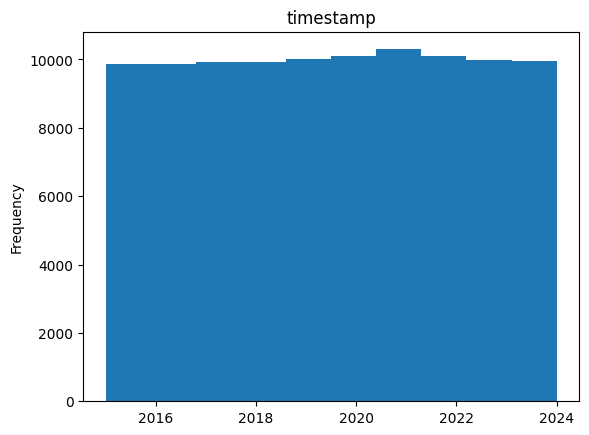

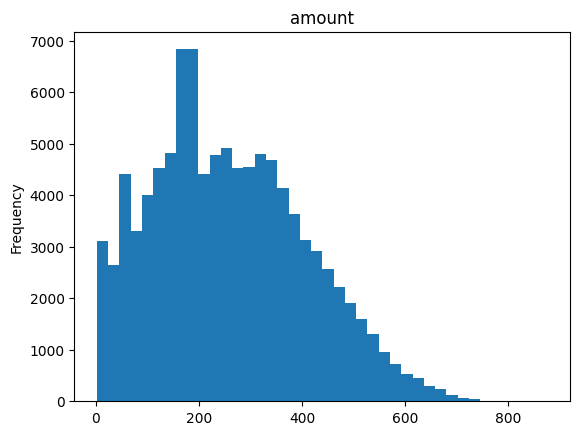

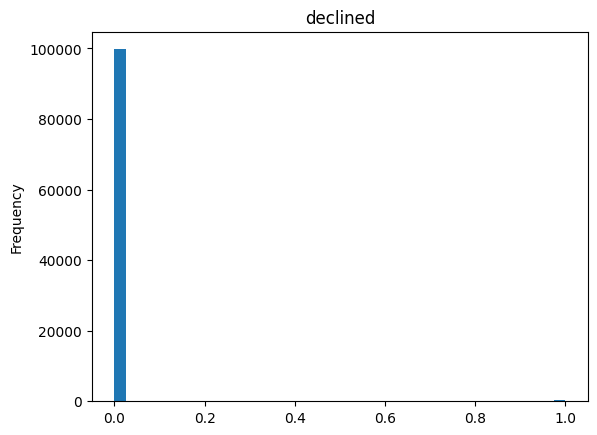

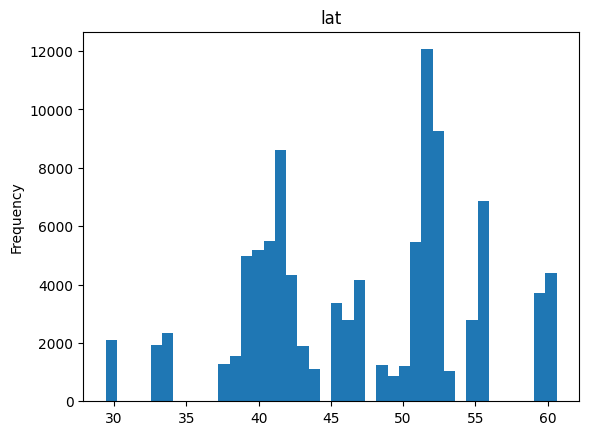

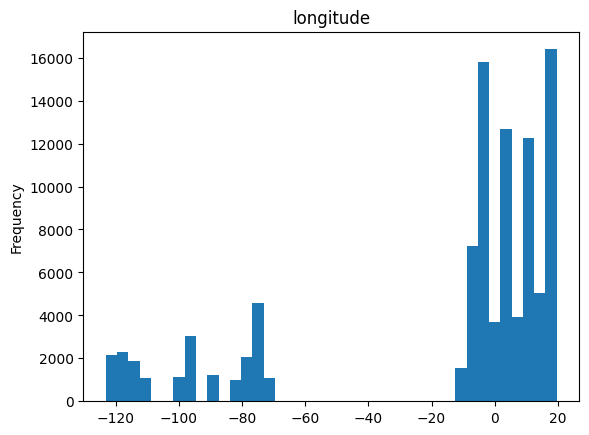

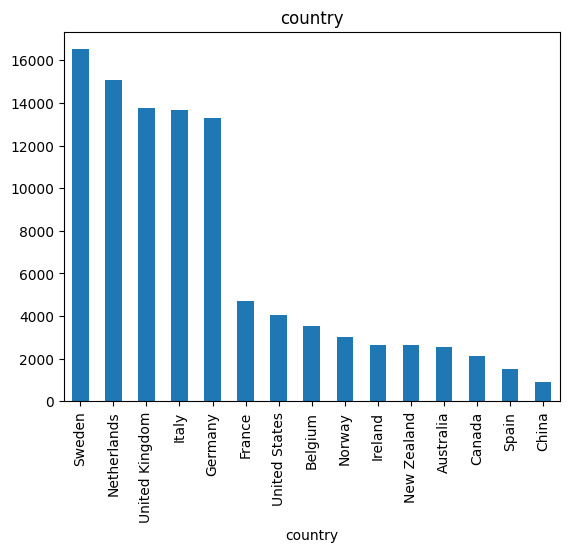

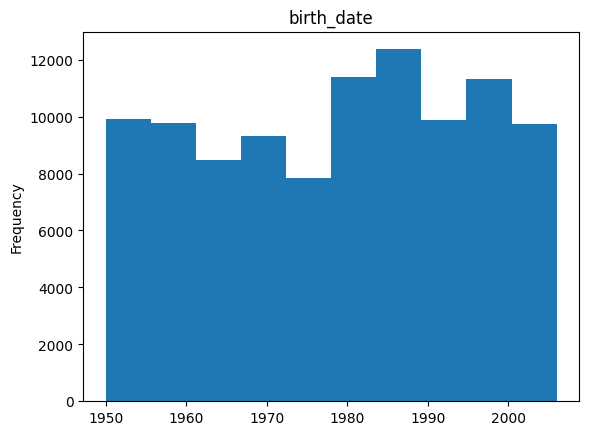

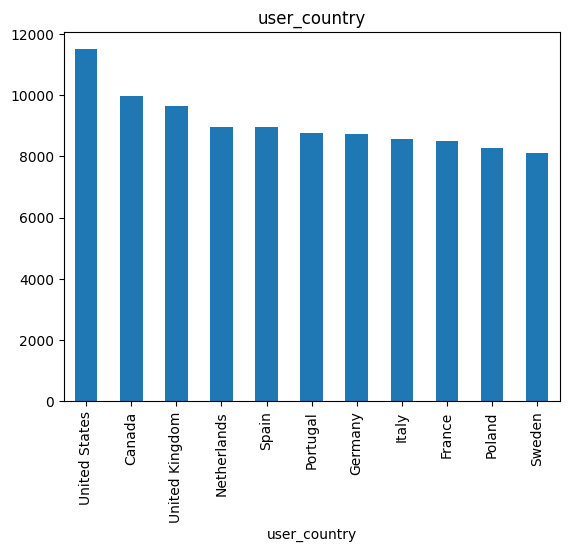

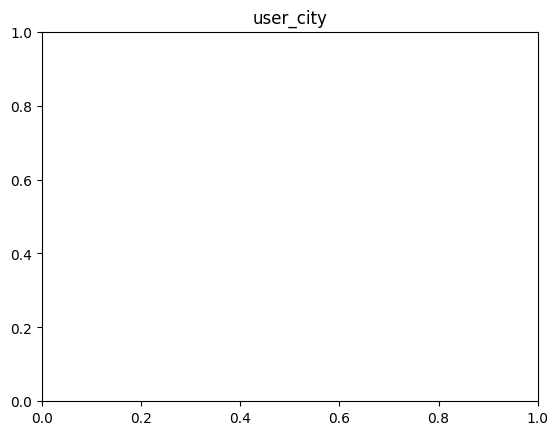

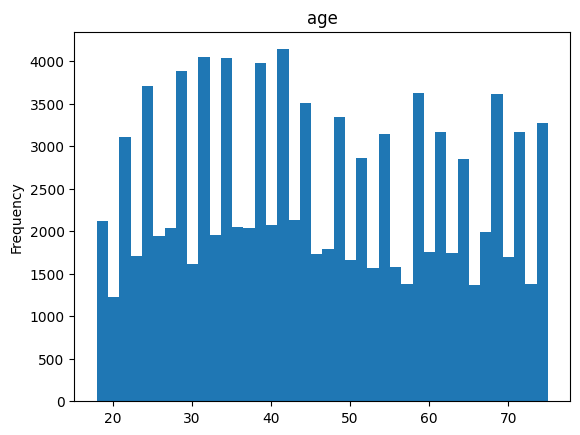

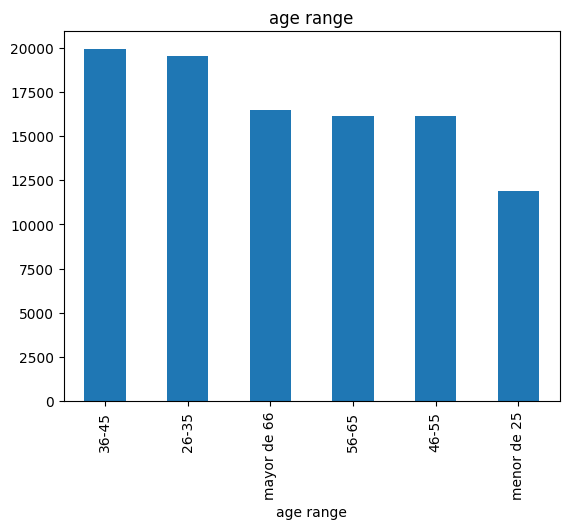

In [21]:
auto_plot(df[['timestamp', 'amount',
       'declined', 'lat', 'longitude', 'country',
       'birth_date', 'user_country', 'user_city', "age", "age range"]])

In [22]:
# Para cada elemento, crea una vista adecuada según las variables especificadas. Interpreta los resultados según sus datos.
    # Dos variables numéricas.
    # Tres variables combinadas.
    # Crea un Pairplot.

df.columns

Index(['id', 'credit_card_id', 'company_id', 'user_id', 'timestamp', 'amount',
       'declined', 'lat', 'longitude', 'company_name', 'telephone', 'email_x',
       'country', 'website', 'user_name', 'surname', 'phone', 'email_y',
       'birth_date', 'user_country', 'user_city', 'postal_code', 'address',
       'age', 'age range'],
      dtype='object')

Text(0.5, 1.0, 'Ventas por país')

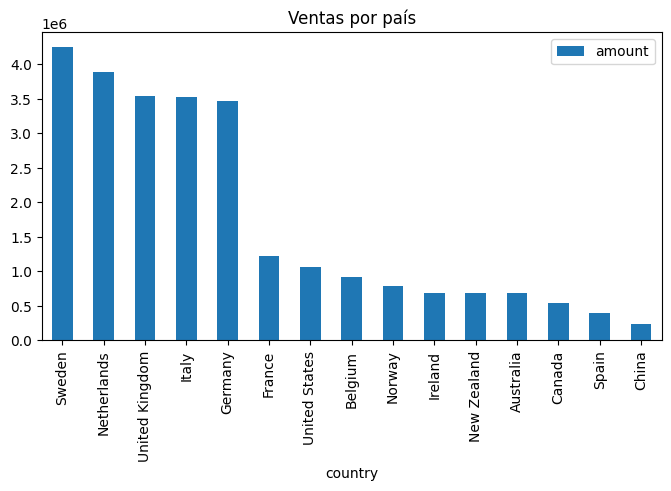

In [23]:
# Una variable categórica y una numérica.
df.groupby("country").agg({"amount":"sum"}).sort_values(by="amount" ,ascending=False).plot.bar(figsize=(8, 4))
plt.title("Ventas por país")


Text(0.5, 1.0, 'Top 10 ventas por empresa')

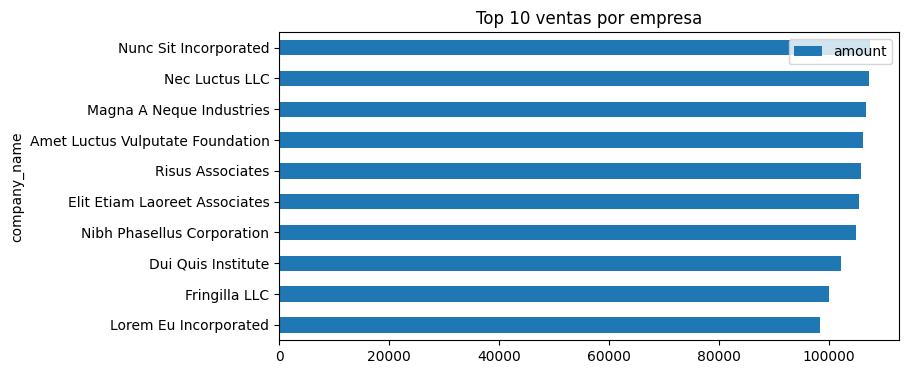

In [24]:
df.groupby("company_name").agg({"amount":"sum"}).sort_values(by="amount" ,ascending=True).head(10).plot.barh(figsize=(8, 4))
plt.title("Top 10 ventas por empresa")

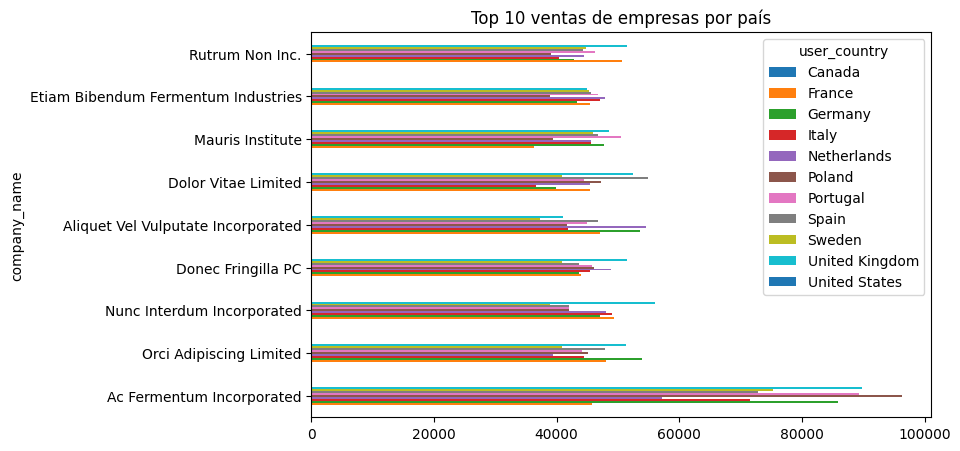

In [56]:
ventas_pais = pd.crosstab(
    df["company_name"], df["user_country"],
    df["amount"], aggfunc="sum",
    margins_name="Ventas totales", margins="sum")\
    .round(0)\
    .sort_values(by="Ventas totales", ascending= False).head(10)

# elimino la fila y columna de ventas totales
ventas_pais = ventas_pais.loc[ventas_pais.index != "Ventas totales"]
ventas_pais = ventas_pais.loc[:, ventas_pais.columns!= "Ventas totales"]

ventas_pais.plot.barh(stacked=False, figsize=(8,5))
plt.title("Top 10 ventas de empresas por país")
plt.show()

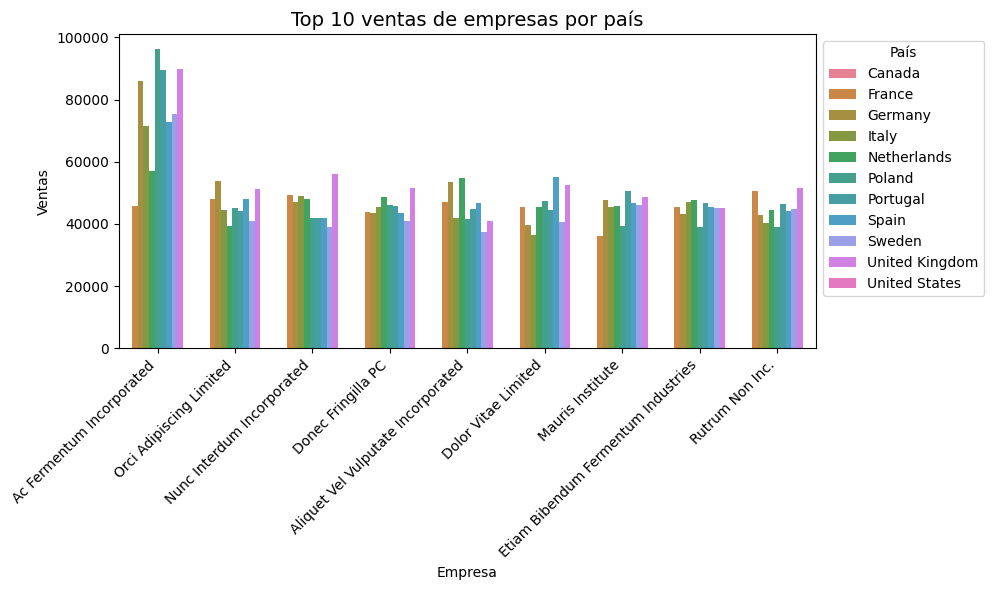

In [58]:
# Paso 1: preparar los datos en formato largo para seaborn
ventas_pais_reset = ventas_pais.reset_index().melt(
    id_vars="company_name",
    var_name="País",
    value_name="Ventas"
)

# gráfico 
plt.figure(figsize=(10,6))
sns.barplot(
    data=ventas_pais_reset,
    x="company_name",
    y="Ventas",
    hue="País")
plt.title("Top 10 ventas de empresas por país", fontsize=14)
plt.xlabel("Empresa")
plt.ylabel("Ventas")
plt.xticks(rotation=45, ha="right")
plt.legend(title="País", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Axes: ylabel='amount'>

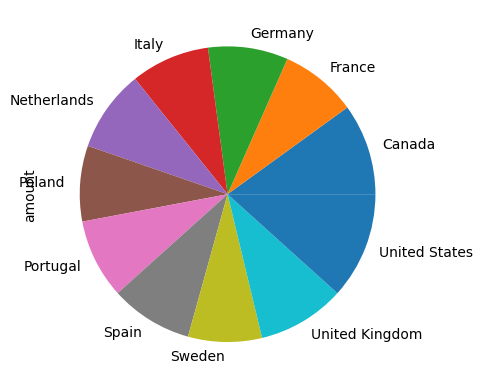

In [27]:
# Una variable categórica y una numérica.
df.groupby("user_country")["amount"].sum().plot.pie()

Text(0.5, 1.0, 'Ventas totales por rango de edad')

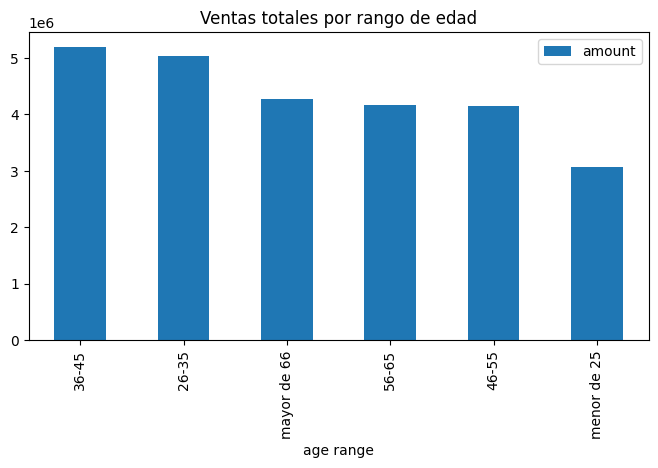

In [28]:
# ventas por rango edad
df.groupby("age range").agg({"amount":"sum"}).sort_values(by="amount" ,ascending=False).plot.bar(figsize=(8, 4))
plt.title("Ventas totales por rango de edad")

Text(0.5, 1.0, 'Ventas totales por país de origen de usuario y rango de edad')

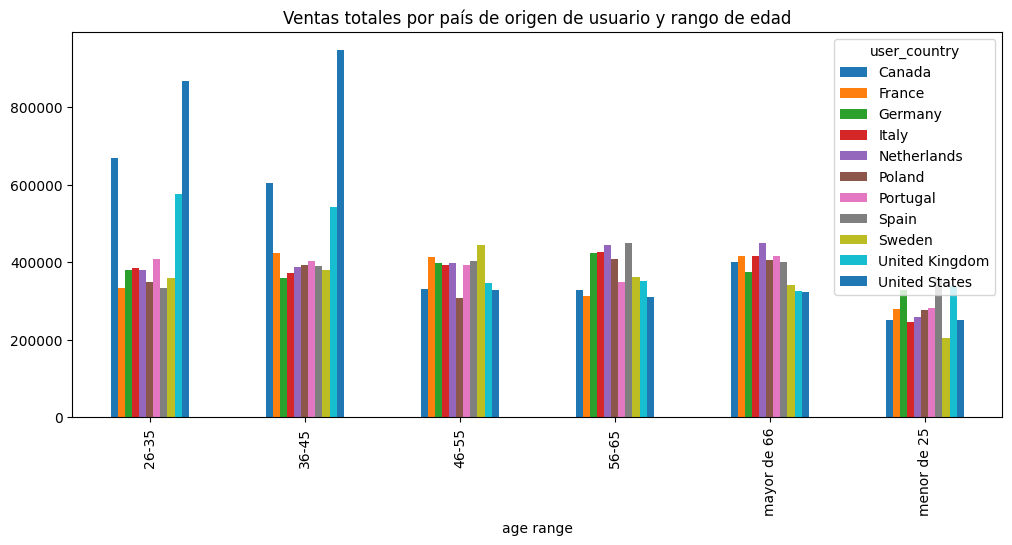

In [29]:
# ventas por pais de origen de usuario y rango de edad
pd.crosstab(df["user_country"],df["age range"], df["amount"], aggfunc="sum").round(0).transpose().plot.bar(figsize=(12,5), stacked=False)
plt.title("Ventas totales por país de origen de usuario y rango de edad")


Text(0.5, 1.0, 'Ventas totales por país de origen de usuario y rango de edad')

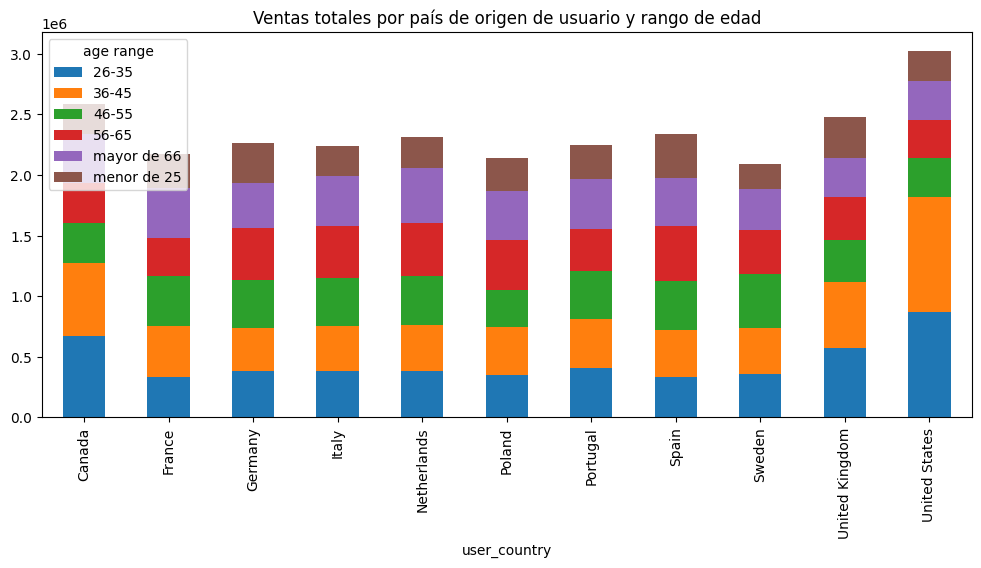

In [30]:
pd.crosstab(df["user_country"],df["age range"], df["amount"], aggfunc="sum").round(0).plot.bar(figsize=(12,5), stacked=True)
plt.title("Ventas totales por país de origen de usuario y rango de edad")

<Axes: ylabel='declined'>

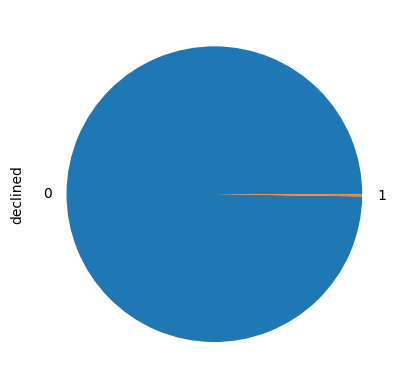

In [31]:
# cantidad de operaciones declinadas
df.groupby("declined")["declined"].count().plot.pie()

Text(0.5, 1.0, 'Cantidad de compañías por país')

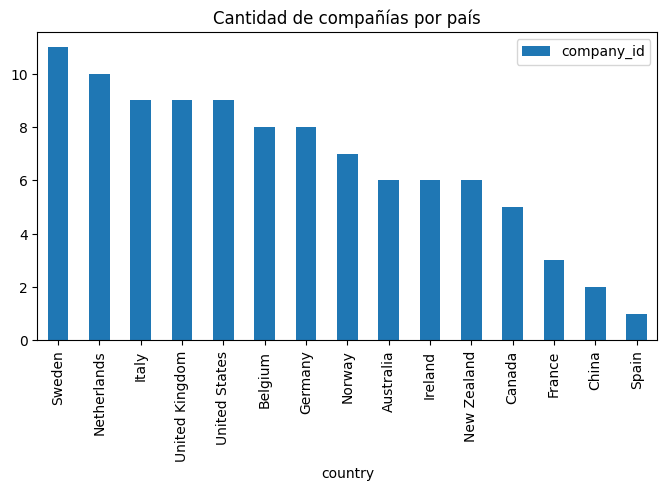

In [32]:
# Dos variables categóricas
df.groupby("country").agg({"company_id":"nunique"}).sort_values(by="company_id" ,ascending=False).plot.bar(figsize=(8, 4))
plt.title("Cantidad de compañías por país")

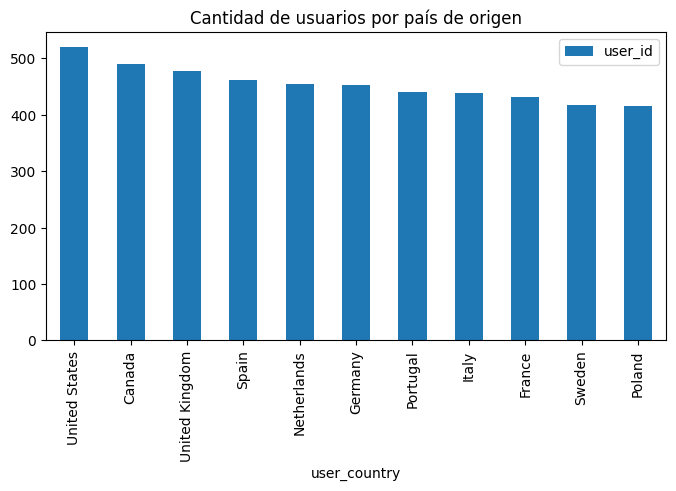

In [33]:
# Dos variables categóricas
df.groupby("user_country").agg({"user_id":"nunique"}).sort_values(by="user_id" ,ascending=False).plot.bar(figsize=(8, 4))
plt.title("Cantidad de usuarios por país de origen")
plt.show()

<Axes: xlabel='timestamp', ylabel='amount'>

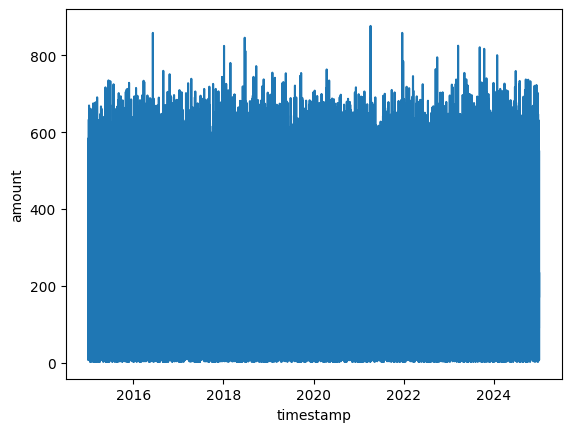

In [34]:
# Dos variables categóricas

import seaborn as sns

sns.lineplot(data=df, x="timestamp", y="amount")


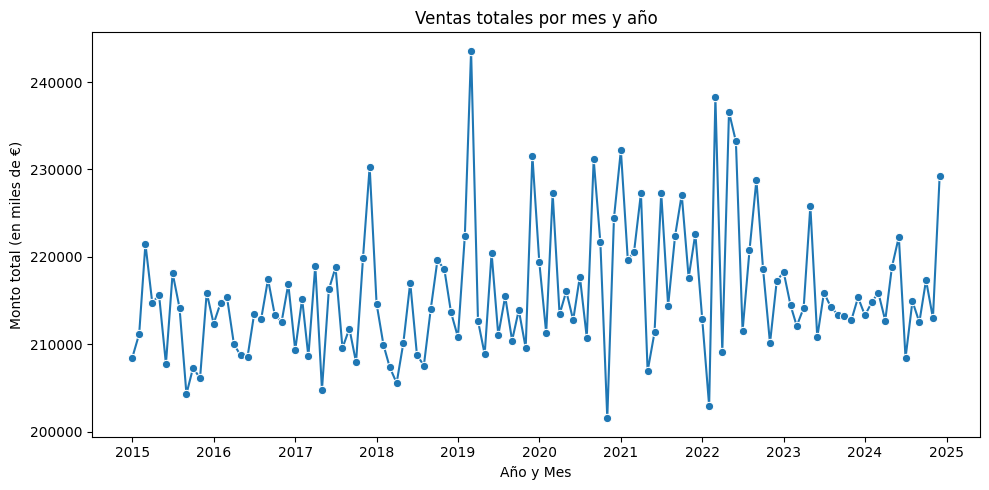

In [59]:
amount_xmes = df.groupby(df['timestamp'].dt.to_period('M'))[['amount']].sum()
amount_xmes.index = amount_xmes.index.to_timestamp()  # convierte Period -> Timestamp
amount_xmes = amount_xmes.reset_index()
amount_xmes

plt.figure(figsize=(10,5))
sns.lineplot(
    data=amount_xmes,
    x='timestamp', y='amount',
    marker='o')
plt.title("Ventas totales por mes y año")
plt.xlabel("Año y Mes")
plt.ylabel("Monto total (en miles de €)")
plt.tight_layout()
plt.show()

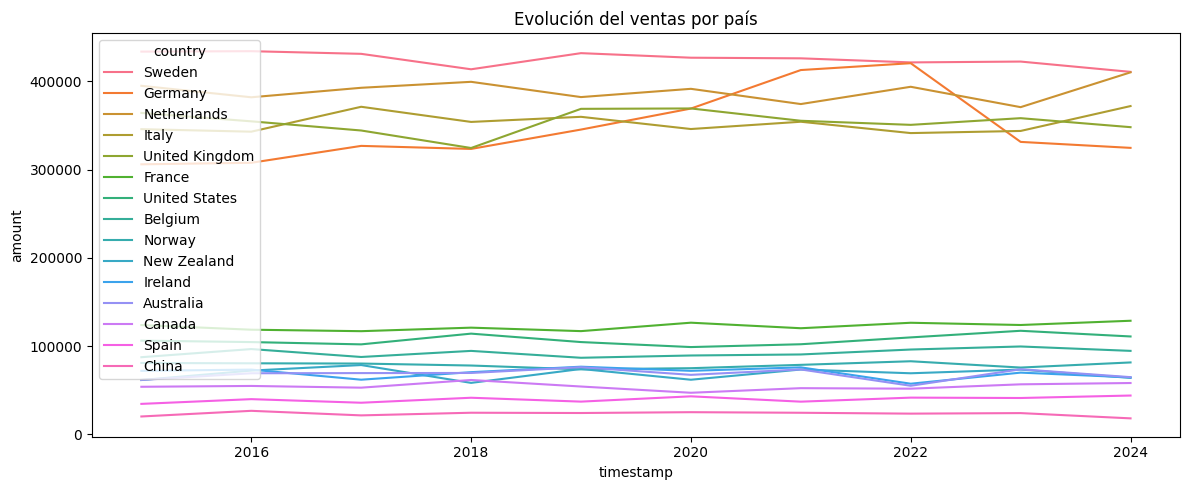

In [36]:
# 3 variables

amount_xaño_pais = df.groupby([df['country'], df["timestamp"].dt.year])[["amount"]].sum()\
    .sort_values(by="amount", ascending=False)\
    .round(0).reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(
    data=amount_xaño_pais,
    x="timestamp",
    y='amount',
    hue= 'country'
)
plt.title("Evolución del ventas por país")
plt.tight_layout()
plt.show()

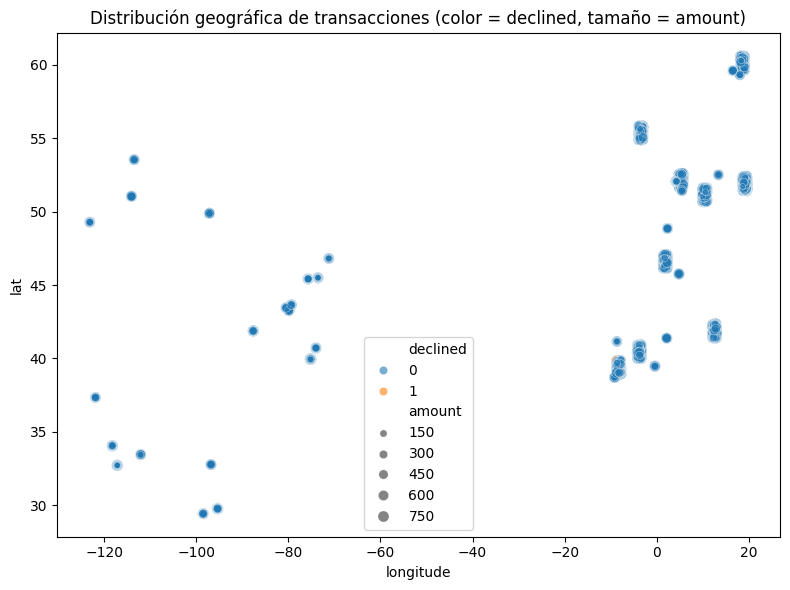

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='longitude',
    y='lat',
    hue='declined',
    size='amount',
    alpha=0.6
)
plt.title("Distribución geográfica de transacciones (color = declined, tamaño = amount)")
plt.tight_layout()
plt.show()

In [38]:
import plotly.express as px

# Agregamos por país
df_country = df.groupby('country').agg(
    monto_total=('amount','sum'),
    transacciones=('id','count')
).reset_index()

# Mapa de burbujas
fig = px.scatter_geo(
    df_country,
    locations='country',      # columna con nombre de país
    locationmode='country names', # Plotly reconoce nombres de países
    size='monto_total',         # tamaño de la burbuja según monto
    hover_name='country',     # al pasar el mouse muestra el país
    hover_data={'monto_total':True, 'transacciones':True},
    projection='natural earth',
    title='Mapa de burbujas por país'
)
fig.update_layout(
    width=1200,
    height=600,
    margin={"r":0,"t":50,"l":0,"b":0}
)
fig.update_geos(
    projection_scale=1.1,
    center={"lat":20, "lon":0}  # ejemplo centrando Europa y África
)
fig.show()

/var/folders/18/mfrphkvn4wq2mf7pmp8_5m2c0000gn/T/ipykernel_34671/2047795178.py:10: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


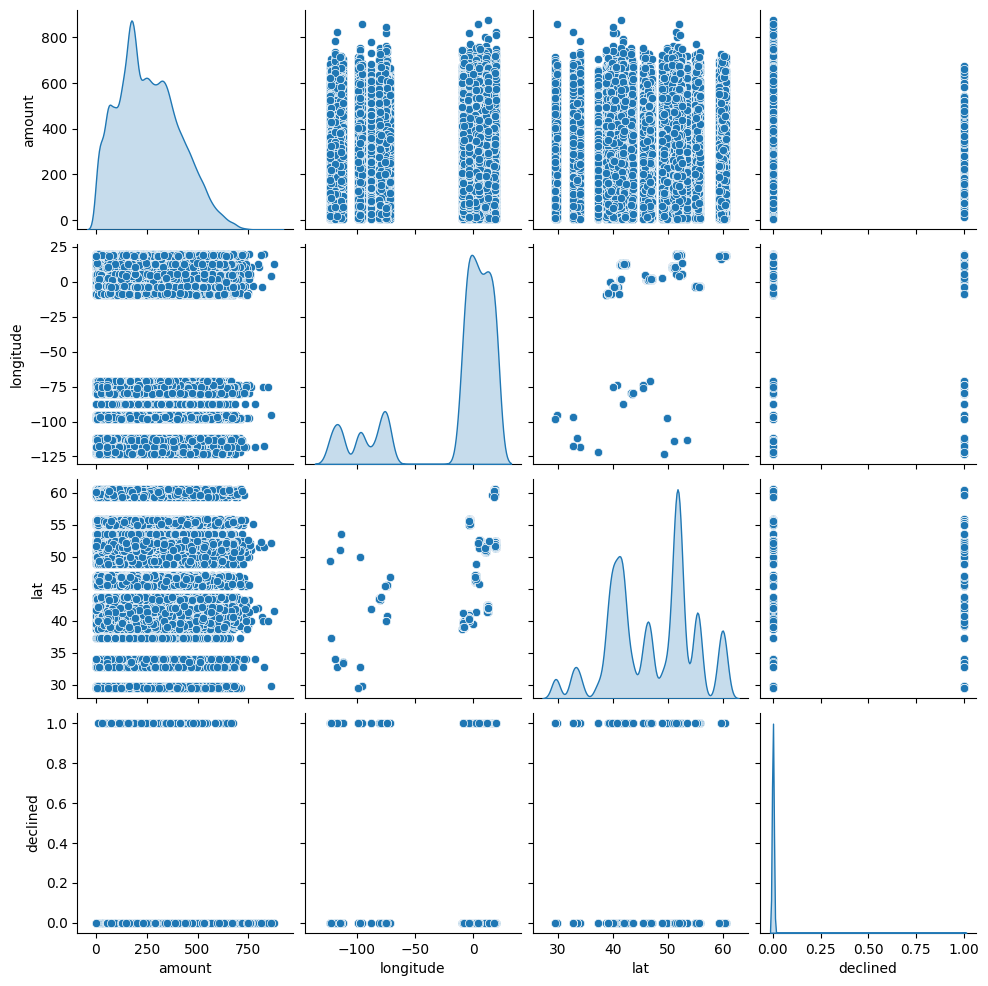

In [39]:
# Crea un Pairplot (solo para numericas)
sns.pairplot(
    df[['amount', 'longitude', 'lat', "declined"]],
    diag_kind="kde"                             #tipo de grafico de la diagonal
)

## NIVEL 2

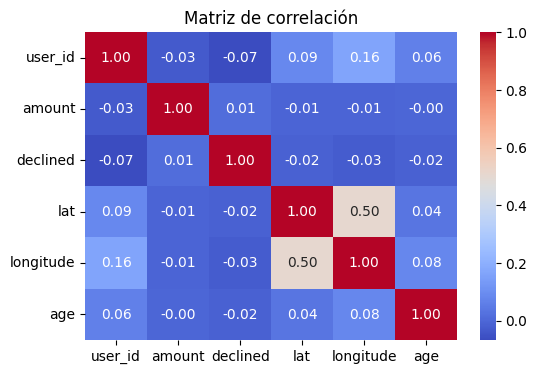

In [40]:
# NIVEL 2 - Ejercicio 1
# Representa la correlación de algunas variables e interpreta los resultados según tus datos.

# Selección de variables numéricas
df_num = df.select_dtypes("number")

# Matriz de correlación
corr = df_num.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Las unicas viables que tendrían una correlacion serian lat y longitud. Positiva y de 0.5, es decir que cuado una aumenta la otra tambien lo hace en la proporcion de 0.5 (la mitad)

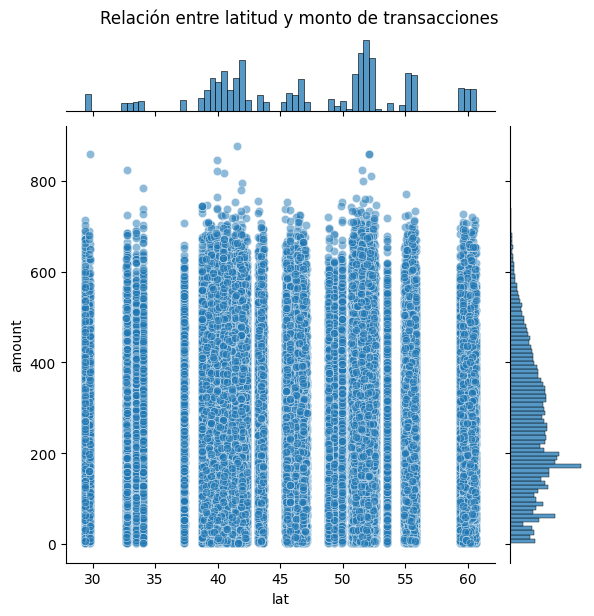

In [41]:
# NIVEL 2 - Ejercicio 2
# Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.

sns.jointplot(
    data=df,
    x='lat',
    y='amount',
    kind='scatter',   # scatterplot con distribución marginal
    alpha=0.5,
    height=6
)
plt.suptitle("Relación entre latitud y monto de transacciones", y=1.02)
plt.show()

## NIVEL 3